MAE — Train      : 15.7661
MAE — Validation : 16.0166


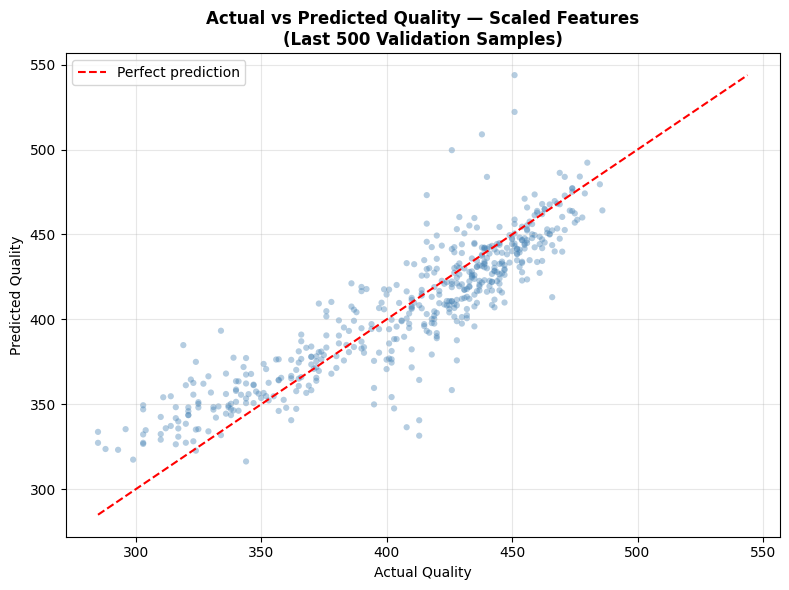

In [ ]:
################ Task 1. a) 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler

# Load data
df = pd.read_csv('roasting_data.csv', parse_dates=['date_time'])

# Define features and target
temperature_cols = [c for c in df.columns if c.startswith('T_data')]
feature_cols = temperature_cols + ['H_data', 'AH_data']
target_col   = 'quality'

# Train / Validation split
TRAIN_SIZE = 24_000
X_train = df.iloc[:TRAIN_SIZE][feature_cols]
y_train = df.iloc[:TRAIN_SIZE][target_col]
X_val   = df.iloc[TRAIN_SIZE:][feature_cols]
y_val   = df.iloc[TRAIN_SIZE:][target_col]

# Scale features — fit ONLY on train, then transform both
scaler        = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)      # use the same train scaler

# Train Linear Regression on scaled features
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Predictions
y_train_pred = model.predict(X_train_scaled)
y_val_pred   = model.predict(X_val_scaled)

# Evaluate
mae_train = mean_absolute_error(y_train, y_train_pred)
mae_val   = mean_absolute_error(y_val,   y_val_pred)
print(f'MAE — Train      : {mae_train:.4f}')
print(f'MAE — Validation : {mae_val:.4f}')

# Plot — Actual vs Predicted (last 500 validation rows)
y_val_last500      = y_val.iloc[-500:].values
y_val_pred_last500 = y_val_pred[-500:]

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_val_last500, y_val_pred_last500,
           alpha=0.4, edgecolors='none', color='steelblue', s=20)

lims = [min(y_val_last500.min(), y_val_pred_last500.min()),
        max(y_val_last500.max(), y_val_pred_last500.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')

ax.set_title('Actual vs Predicted Quality — Scaled Features\n(Last 500 Validation Samples)', fontweight='bold')
ax.set_xlabel('Actual Quality')
ax.set_ylabel('Predicted Quality')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roasting_predictions_scaled.png', dpi=150, bbox_inches='tight')
plt.show()

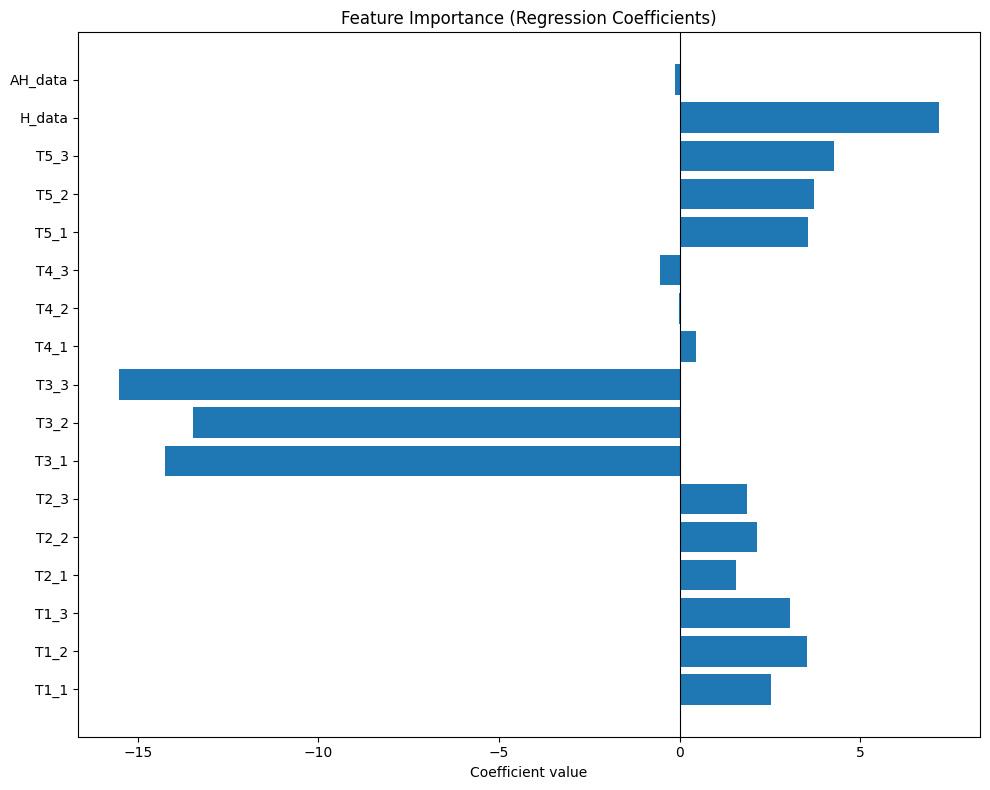


Features ranked by absolute coefficient:
Feature  Coefficient
   T3_3   -15.516369
   T3_1   -14.252220
   T3_2   -13.482316
 H_data     7.184141
   T5_3     4.269995
   T5_2     3.725981
   T5_1     3.567647
   T1_2     3.521532
   T1_3     3.053357
   T1_1     2.544786
   T2_2     2.157590
   T2_3     1.872448
   T2_1     1.559187
   T4_3    -0.552294
   T4_1     0.459762
AH_data    -0.139351
   T4_2    -0.020943


In [ ]:
# Task 2 — Feature Importance via Regression Coefficients


features_importance = model.coef_

# Shorten feature names for readability on the chart
feature_names = (
    [f'T{i//3+1}_{i%3+1}' for i in range(len(temperature_cols))]  # T1_1, T1_2 ... T5_3
    + ['H_data', 'AH_data']
)

# Plot horizontal bar chart
plt.figure(figsize=(10, 8))
plt.barh(feature_names, features_importance)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Feature Importance (Regression Coefficients)')
plt.xlabel('Coefficient value')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Print ranked importance
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': features_importance})
coef_df = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=False).index)
print('\nFeatures ranked by absolute coefficient:')
print(coef_df.to_string(index=False))

In [ ]:
################ Task 1. b) 

# Known inputs

temperatures = [231, 232, 229, 301, 353, 313, 530, 530, 549, 350, 349, 333, 212, 219, 206]
moisture     = 7.31        # AH_data
target_quality = 350

known_values = temperatures + [moisture]   # 15 temps + AH_data

# H_data (thickness) is the second-to-last column, AH_data is last
# feature_cols = [...T_data_*, H_data, AH_data]
# So H_data index is -2, AH_data is -1

coef_known = np.concatenate([model.coef_[:-2], model.coef_[-1:]])  # all except H_data
coef_H     = model.coef_[-2]   # coefficient for H_data (thickness)

# Scale known features with placeholder for H_data
placeholder_row = np.array(temperatures + [0.0] + [moisture]).reshape(1, -1)  # H_data=0 placeholder
scaled_row      = scaler.transform(placeholder_row)

# Extract scaled known parts (all except H_data at index -2)
scaled_known = np.concatenate([scaled_row[0, :-2], scaled_row[0, -1:]])

# H_data scaling parameters
H_mean = scaler.mean_[-2]
H_std  = scaler.scale_[-2]

# Solve for scaled H_data
scaled_H = (target_quality - model.intercept_ - np.dot(coef_known, scaled_known)) / coef_H

# Inverse-scale to get actual H_data value
required_thickness = scaled_H * H_std + H_mean

print(f'Required H_data (thickness) for quality ≥ {target_quality}: {required_thickness:.2f}')

# ── Verify ────────────────────────────────────────────────────────────────────
full_row        = np.array(temperatures + [required_thickness] + [moisture]).reshape(1, -1)
full_row_scaled = scaler.transform(full_row)
predicted_quality = model.predict(full_row_scaled)[0]

print(f'Verification — predicted quality with this thickness: {predicted_quality:.2f}')

Required H_data (thickness) for quality ≥ 350: 168.84
Verification — predicted quality with this thickness: 350.00


/Users/dineshbisht/masterdegree/myproject_env/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/dineshbisht/masterdegree/myproject_env/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler

# Load data
df = pd.read_csv('roasting_data.csv', parse_dates=['date_time'])

# Define features and target
# temperature_cols = [c for c in df.columns if c.startswith('T_data')]
temperature_cols = [c for c in df.columns if c.startswith('T_data') and not c.startswith('T_data_4')]
# feature_cols     = temperature_cols + ['H_data', 'AH_data']
feature_cols     = temperature_cols + ['H_data']
target_col       = 'quality'

# Train / Validation split
TRAIN_SIZE   = 24_000
X_train = df.iloc[:TRAIN_SIZE][feature_cols]
y_train = df.iloc[:TRAIN_SIZE][target_col]
X_val   = df.iloc[TRAIN_SIZE:][feature_cols]
y_val   = df.iloc[TRAIN_SIZE:][target_col]

# Scale features — fit ONLY on train, then transform both
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)

# Build Neural Network
nn_model = tf.keras.Sequential([
    tf.keras.layers.Dense(30, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dense(30, activation='tanh'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(30, activation='relu'),
    tf.keras.layers.Dense(1)   # single output: quality
])

nn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

# nn_model.summary()

# Train
history = nn_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    batch_size=32,
    # verbose=0  # uncomment for silent training
)

# Predictions
y_train_pred = nn_model.predict(X_train_scaled).flatten()
y_val_pred   = nn_model.predict(X_val_scaled).flatten()

# Evaluate
mae_train = mean_absolute_error(y_train, y_train_pred)
mae_val   = mean_absolute_error(y_val,   y_val_pred)
print(f'MAE — Train      : {mae_train:.4f}')
print(f'MAE — Validation : {mae_val:.4f}')

Epoch 1/50


/Users/dineshbisht/masterdegree/myproject_env/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 447us/step - loss: 80331.3828 - mae: 244.7069 - val_loss: 6844.1704 - val_mae: 49.8043
Epoch 2/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 342us/step - loss: 9472.8711 - mae: 69.9076 - val_loss: 3936.7078 - val_mae: 38.8888
Epoch 3/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 337us/step - loss: 6297.6680 - mae: 59.8239 - val_loss: 1436.4762 - val_mae: 28.3012
Epoch 4/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 341us/step - loss: 3243.1917 - mae: 44.7111 - val_loss: 656.4175 - val_mae: 19.5517
Epoch 5/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 338us/step - loss: 1917.8596 - mae: 33.9412 - val_loss: 533.9361 - val_mae: 17.5769
Epoch 6/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 338us/step - loss: 1321.4290 - mae: 28.2585 - val_loss: 492.4452 - val_mae: 16.7492
Epoch 7/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 344us/step - loss: 1260.4725 - mae: 27.6256 - val_loss: 532.8828 - val_mae: 17.4391
Epoch 8/50
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 337us/step - loss: 990.1325 - mae: 24.2948 - val_loss: 436.0538 - val_mae: